# Term Deposit Marketing Model

## Importing Modules

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, auc

import pandas as pd
import matplotlib.pyplot as plt

print('Modules Imported')

Modules Imported


## Loading the Dataset

In [2]:
file_path = 'term-deposit-marketing-2020.csv'

data = pd.read_csv(file_path)

In [4]:
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,technician,married,tertiary,no,395,no,no,cellular,3,jun,107,1,no
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,yes
39997,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1,yes
39998,34,management,married,tertiary,no,1047,no,no,cellular,3,jun,342,1,no


- age : age of customer (numeric)

- job : type of job (categorical)

- marital : marital status (categorical)

- education (categorical)

- default: has credit in default? (binary)

- balance: average yearly balance, in euros (numeric)

- housing: has a housing loan? (binary)

- loan: has personal loan? (binary)

- contact: contact communication type (categorical)

- day: last contact day of the month (numeric)

- month: last contact month of year (categorical)

- duration: last contact duration, in seconds (numeric)

- campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)

 y - has the client subscribed to a term deposit? (binary)

Detecting Na values

In [6]:
data.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

## Data Analisys

### Class Balance

In [30]:
customers = data.groupby('y').size()

total_customers = data['y'].count()

customers_opinions = ['Did not Subscribed', 'Subscribed']

color = ['r','g']

types_of_customers = data.groupby('y').size().index

plt.pie(customers*100/total_customers, labels = customers_opinions, colors= color, radius=0.85, alpha=0.5)
plt.legend(loc='lower right')
plt.title("Distribution of Customers")
plt.show()

TypeError: pie() got an unexpected keyword argument 'alpha'

This shows that the proportion of customers that did not deposit is way higher than those who deposited

### Age

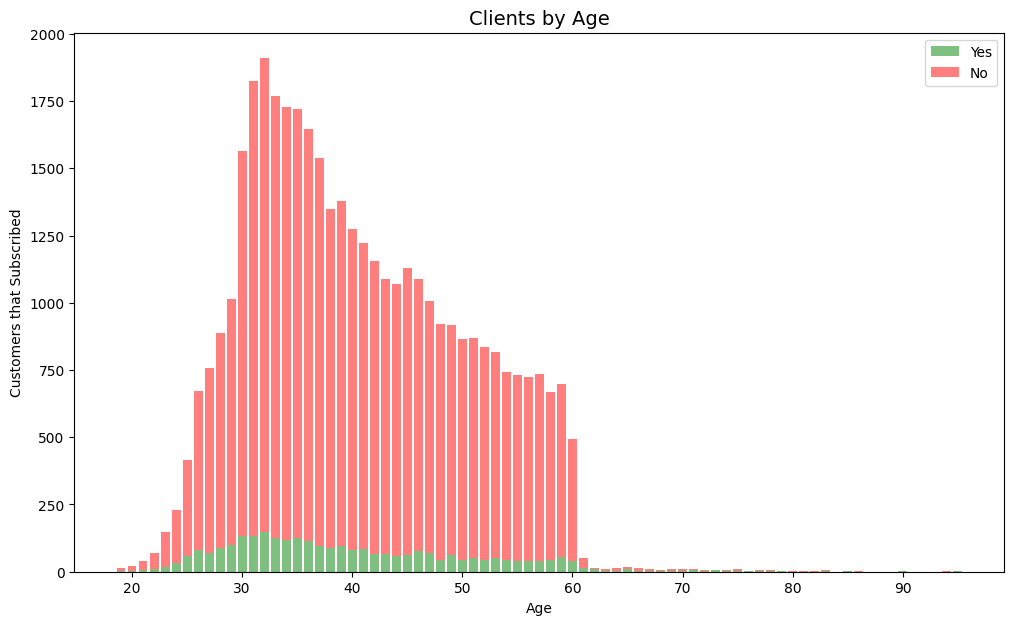

In [20]:
# Setting the data for the satisfied clients
n_satisfied_clients = (
    data[data['y'] == 'yes']
    .groupby('age')
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    data[data['y'] == 'no']
    .groupby('age')
    .size()
)

# Setting the index for all clients
all_clients = sorted(data['age'].unique())

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients,fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients,fill_value=0)

# Standardizing the x axis for both graphs
x_axis = data.groupby('age').size().index

f, (ax1) = plt.subplots(1, figsize=(12,7))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Age")
ax1.set_title("Clients by Age",fontsize=14)
plt.legend(loc='upper right')

### Job

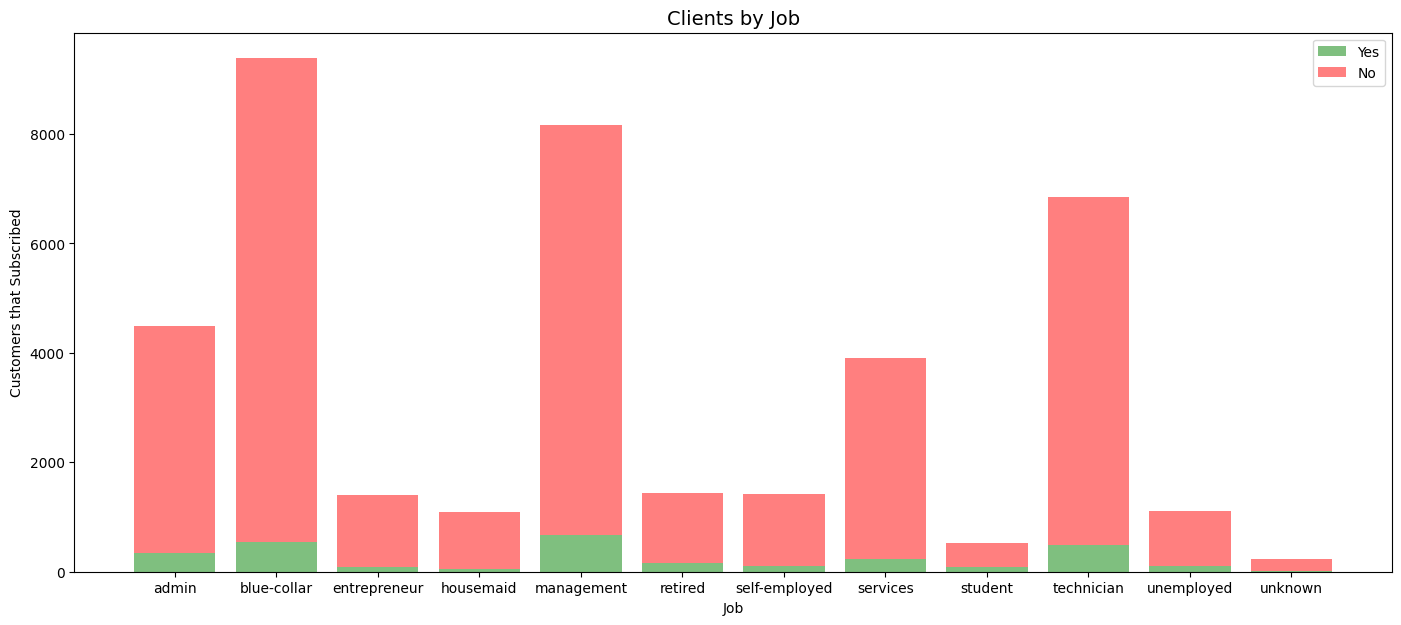

In [23]:
# Setting the data for the satisfied clients
n_satisfied_clients = (
    data[data['y'] == 'yes']
    .groupby('job')
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    data[data['y'] == 'no']
    .groupby('job')
    .size()
)

# Setting the index for all clients
all_clients = sorted(data['job'].unique())

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients,fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients,fill_value=0)

# Standardizing the x axis for both graphs
x_axis = data.groupby('job').size().index

f, (ax1) = plt.subplots(1, figsize=(17,7))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Job")
ax1.set_title("Clients by Job",fontsize=14)
plt.legend(loc='upper right')

### Marital

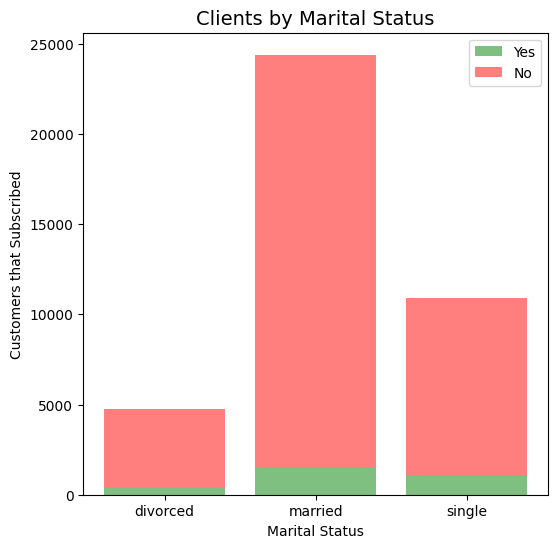

In [28]:
# Setting the data for the satisfied clients
n_satisfied_clients = (
    data[data['y'] == 'yes']
    .groupby('marital')
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    data[data['y'] == 'no']
    .groupby('marital')
    .size()
)

# Setting the index for all clients
all_clients = sorted(data['marital'].unique())

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients,fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients,fill_value=0)

# Standardizing the x axis for both graphs
x_axis = data.groupby('marital').size().index

f, (ax1) = plt.subplots(1, figsize=(6,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Marital Status")
ax1.set_title("Clients by Marital Status",fontsize=14)
plt.legend(loc='upper right')

### Education

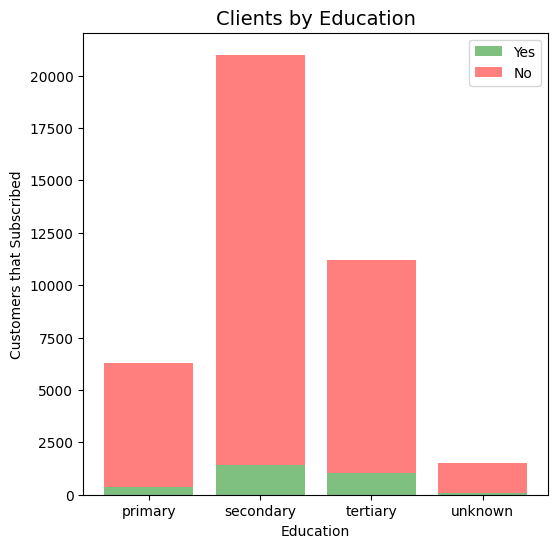

In [29]:
# Setting the data for the satisfied clients
n_satisfied_clients = (
    data[data['y'] == 'yes']
    .groupby('education')
    .size()
)

# Setting the data for the unsatisfied clients
n_unsatisfied_clients = (
    data[data['y'] == 'no']
    .groupby('education')
    .size()
)

# Setting the index for all clients
all_clients = sorted(data['education'].unique())

# Filling gaps of non-existing data
n_satisfied_clients = n_satisfied_clients.reindex(all_clients,fill_value=0)
n_unsatisfied_clients = n_unsatisfied_clients.reindex(all_clients,fill_value=0)

# Standardizing the x axis for both graphs
x_axis = data.groupby('education').size().index

f, (ax1) = plt.subplots(1, figsize=(6,6))

# First Graph
ax1.bar(x_axis, n_satisfied_clients, label='Yes', alpha=0.5, color='g')
ax1.bar(x_axis, n_unsatisfied_clients, bottom=n_satisfied_clients, label='No', alpha=0.5, color='r')

plt.sca(ax1)

ax1.set_ylabel("Customers that Subscribed")
ax1.set_xlabel("Education")
ax1.set_title("Clients by Education",fontsize=14)
plt.legend(loc='upper right')